In [1]:
print("hi")

hi


In [2]:
%pip install pandas -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### convert data of lat and lng to the enu coordination

Transformed GPS Data (First 5 Rows):
             timestamp       x_m        y_m
0  1703098100378834176  0.000000   0.000000
1  1703098100587210240  0.894130  -3.926293
2  1703098100795555072  2.245108  -7.534237
3  1703098101003794944  3.976167 -10.781387
4  1703098101212150016  6.038385 -13.662158


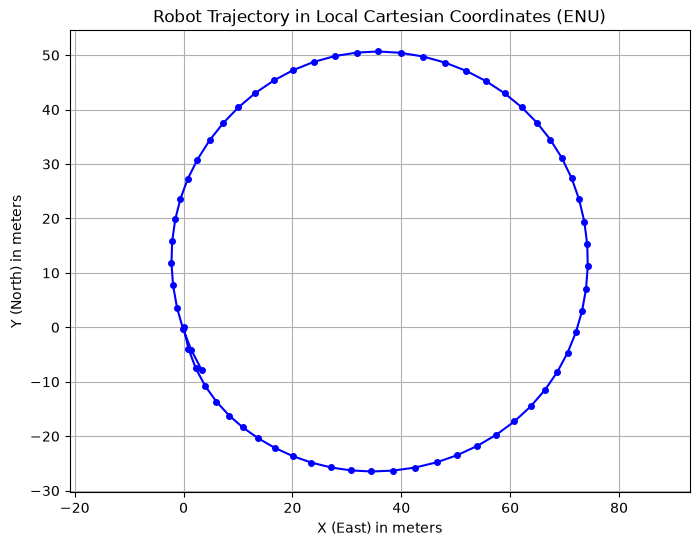

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def convert_gps_to_enu(df_gps):
    
    lat_rad = np.deg2rad(df_gps['lat'])
    lon_rad = np.deg2rad(df_gps['lon'])

    R = 6400 * 1000 # convert to meter

    lat_0 = lat_rad.iloc[0]
    lon_0 = lon_rad.iloc[0]


    df_gps['x_m'] = R * (lon_rad - lon_0) * np.cos(lat_0)
    df_gps['y_m'] = R * (lat_rad - lat_0)

    return df_gps

df_gps = pd.read_csv('./data/gps.txt')
df_gps.columns = df_gps.columns.str.strip()
gps_data_transformed = convert_gps_to_enu(df_gps)




print("Transformed GPS Data (First 5 Rows):")
print(gps_data_transformed[['timestamp', 'x_m', 'y_m']].head())
gps_data_transformed.to_csv('./data/gps_transformed.csv', index=False)





plt.figure(figsize=(8, 6))
plt.plot(gps_data_transformed['x_m'], gps_data_transformed['y_m'], marker='o', markersize=4, linestyle='-', color='b')
plt.title('Robot Trajectory in Local Cartesian Coordinates (ENU)')
plt.xlabel('X (East) in meters')
plt.ylabel('Y (North) in meters')
plt.grid(True)
plt.axis('equal') 
plt.show()

### create jacobian matrix

In [ ]:
import numpy as np

def calculate_jacobian_F(X_prev, U_t, dt):
    """
    Calculates the Jacobian matrix of the system transition model (F_t).
    X_prev previous state, U_t command input, dt time change
    """
    psi = X_prev[4]  
    ax_B = U_t[0]    
    ay_B = U_t[1]    
    
    sin_psi = np.sin(psi)
    cos_psi = np.cos(psi)
    
    d_ax_G_d_psi = -ax_B * sin_psi - ay_B * cos_psi
    d_ay_G_d_psi =  ax_B * cos_psi - ay_B * sin_psi
    
    # all the diagonal is 1, and the rest is 0, except for the last column so I start with the identity matrix
    F = np.eye(5)
    
    
    F[0, 2] = dt
    F[1, 3] = dt
    
    F[0, 4] = 0.5 * d_ax_G_d_psi * (dt ** 2)
    F[1, 4] = 0.5 * d_ay_G_d_psi * (dt ** 2)
    
    F[2, 4] = d_ax_G_d_psi * dt
    F[3, 4] = d_ay_G_d_psi * dt
    
    return F

### update funciton

In [ ]:
import numpy as np

def update(X_pred, P_pred, Z_meas, H, Q_obs):
    """
    Updates the state and covariance matrices based on a new linear observation.
    
    X_pred (previous state), P_pred (predicted cov), Z_meas (Gps observation),
    H (this is matrix that convert obs to state), Q_obs (obs noise cov)
    output: state, pre cov
    """
    y = Z_meas - np.dot(H, X_pred)
    
    S = np.dot(H, np.dot(P_pred, H.T)) + Q_obs
    
    K = np.dot(P_pred, np.dot(H.T, np.linalg.inv(S)))
    
    X_upd = X_pred + np.dot(K, y)
    
    I = np.eye(P_pred.shape[0])
    P_upd = np.dot((I - np.dot(K, H)), P_pred)
    
    return X_upd, P_upd

### genrate initial state

In [ ]:
import numpy as np

def initialize_state(gps_row_0, gps_row_1, R=6400000):
    "estimate initial state using first 2 observation"


    lat0 = np.deg2rad(gps_row_0['lat'])
    lon0 = np.deg2rad(gps_row_0['lon'])
    
    lat1 = np.deg2rad(gps_row_1['lat'])
    lon1 = np.deg2rad(gps_row_1['lon'])
    

    dt = (gps_row_1['timestamp'] - gps_row_0['timestamp']) * 1e-9
    print(f"this is initial values time difference:{dt}")

    x0 = 0.0
    y0 = 0.0
    
    x1 = R * (lon1 - lon0) * np.cos(lat0)
    y1 = R * (lat1 - lat0)
    
    v_x0 = (x1 - x0) / dt
    v_y0 = (y1 - y0) / dt
    
    psi0 = np.arctan2(v_y0, v_x0)

    print(f"the result of initialize_state x0:{x0}, y0:{y0}, x1:{x1}, y1:{y1},  v_x0:{v_x0}, v_y0:{v_y0}, psi0{psi0}")
          
    X_0 = np.array([
        [x0],
        [y0],
        [v_x0],
        [v_y0],
        [psi0]
    ])
    
    return X_0

df_gps = pd.read_csv('./data/gps.txt')

df_gps.columns = df_gps.columns.str.strip()
initialize_state(df_gps.iloc[0], df_gps.iloc[1])

this is initial values time difference:0.208376064
the result of initialize_state x0:0.0, y0:0.0, x1:0.8941295662738699, y1:-3.926292685463295,  v_x0:4.290941815053527, v_y0:-18.84234019058588, psi0-1.34688618218586


array([[  0.        ],
       [  0.        ],
       [  4.29094182],
       [-18.84234019],
       [ -1.34688618]])

### run updates and predicts and save resulting and save state and location in the history 

I'have not create function of predict and do it in the code unfonctional, but for the update I have written function

In [ ]:
import pandas as pd
import numpy as np

def run_ekf(df_imu, df_gps, X_0, P_0, R, Q, H):
    t_start = df_gps['timestamp'].iloc[1]
    
    df_imu_filtered = df_imu[df_imu['timestamp'] > t_start].copy()
    df_gps_filtered = df_gps[df_gps['timestamp'] > t_start].copy()
    
    df_imu_filtered['sensor_type'] = 'imu'
    df_gps_filtered['sensor_type'] = 'gps'
    
    df_combined = pd.concat([df_imu_filtered, df_gps_filtered], ignore_index=True)
    df_combined = df_combined.sort_values(by='timestamp').reset_index(drop=True)
    
    X_curr = X_0.copy()
    P_curr = P_0.copy()
    
    prev_time = t_start * 1e-9
    
    history = {
        'time': [],
        'X': [],
        'P': [],
        'type': [] # update or predict
    }
    
    for index, row in df_combined.iterrows():
        curr_time = row['timestamp'] * 1e-9
        dt = curr_time - prev_time
        
        if dt <= 0 and index > 0:
            dt = 1e-6 
            
        if row['sensor_type'] == 'imu':
            #(Prediction)
            U_t = np.array([row['ax(m/s^2)'], row['ay(m/s^2)'], row['gz(rad/s)']])
            F_t = calculate_jacobian_F(X_curr.flatten(), U_t, dt)
            
            psi = X_curr[4, 0]
            ax_B, ay_B, omega = U_t[0], U_t[1], U_t[2]
            ax_G = ax_B * np.cos(psi) - ay_B * np.sin(psi)
            ay_G = ax_B * np.sin(psi) + ay_B * np.cos(psi)
            
            X_pred = np.zeros((5, 1))
            X_pred[0, 0] = X_curr[0, 0] + X_curr[2, 0]*dt + 0.5*ax_G*(dt**2)
            X_pred[1, 0] = X_curr[1, 0] + X_curr[3, 0]*dt + 0.5*ay_G*(dt**2)
            X_pred[2, 0] = X_curr[2, 0] + ax_G*dt
            X_pred[3, 0] = X_curr[3, 0] + ay_G*dt
            X_pred[4, 0] = X_curr[4, 0] + omega*dt
            
            P_pred = np.dot(F_t, np.dot(P_curr, F_t.T)) + R
            
            X_curr = X_pred
            P_curr = P_pred
            prev_time = curr_time
            
            history['time'].append(curr_time)
            history['X'].append(X_curr.copy())
            history['P'].append(P_curr.copy())
            history['type'].append('predict')
            
        elif row['sensor_type'] == 'gps':
            #(َUpdate)
            Z_meas = np.array([[row['x_m']], [row['y_m']]])   
            X_curr, P_curr = update(X_curr, P_curr, Z_meas, H, Q)
            
            history['time'].append(curr_time)
            history['X'].append(X_curr.copy())
            history['P'].append(P_curr.copy())
            history['type'].append('update')

    return history

### plot history

In [ ]:
from matplotlib.patches import Ellipse
def plot_covariance_ellipse(pos, cov, ax, n_std=3.0, **kwargs):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:,order]
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)
    ellip = Ellipse(xy=pos, width=width, height=height, angle=theta, **kwargs)
    ellip.set_facecolor('none')
    ax.add_patch(ellip)

### read data, run ekf, and plot

this is initial values time difference:0.208376064
the result of initialize_state x0:0.0, y0:0.0, x1:0.8941295662738699, y1:-3.926292685463295,  v_x0:4.290941815053527, v_y0:-18.84234019058588, psi0-1.34688618218586


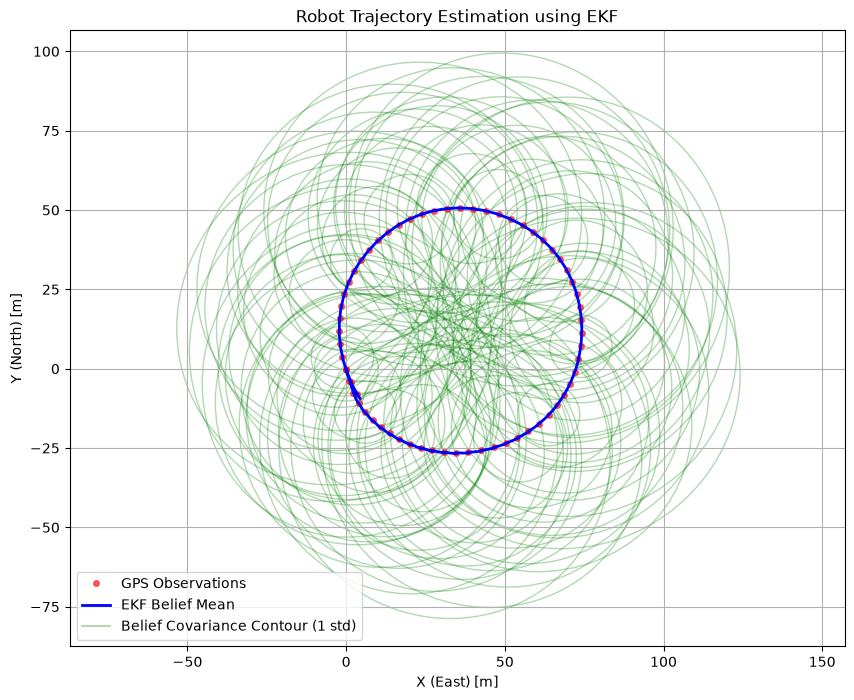

In [ ]:
df_gps = pd.read_csv('./data/gps.txt')
df_imu = pd.read_csv('./data/imu.txt')

df_gps.columns = df_gps.columns.str.strip()
df_imu.columns = df_imu.columns.str.strip()

df_gps = convert_gps_to_enu(df_gps)

X_0 = initialize_state(df_gps.iloc[0], df_gps.iloc[1])
P_0 = np.eye(5) * 1.0

R = np.diag([100, 100, 16, 16, 0.25])
Q = np.diag([100, 100])
H = np.array([[1, 0, 0, 0, 0],
              [0, 1, 0, 0, 0]])

history = run_ekf(df_imu, df_gps, X_0, P_0, R, Q, H)




ekf_x = [state[0, 0] for state in history['X']]
ekf_y = [state[1, 0] for state in history['X']]
covariances = [cov[0:2, 0:2] for cov in history['P']]




fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(df_gps['x_m'], df_gps['y_m'], 'r.', markersize=8, label='GPS Observations', alpha=0.6)
ax.plot(ekf_x, ekf_y, 'b-', linewidth=2, label='EKF Belief Mean')

step = max(len(ekf_x) // 100, 1)
for i in range(0, len(ekf_x), step):
    pos = (ekf_x[i], ekf_y[i])
    cov = covariances[i]
    plot_covariance_ellipse(pos, cov, ax, n_std=1.0, edgecolor='g', alpha=0.3)

ax.plot([], [], color='g', alpha=0.3, label='Belief Covariance Contour (1 std)')

ax.set_title('Robot Trajectory Estimation using EKF')
ax.set_xlabel('X (East) [m]')
ax.set_ylabel('Y (North) [m]')
ax.legend()
ax.grid(True)
ax.axis('equal')
plt.savefig('ekf_trajectory_cov.png', dpi=300)
plt.show()

### run with std = 100 for the observation noise 

this is initial values time difference:0.208376064
the result of initialize_state x0:0.0, y0:0.0, x1:0.8941295662738699, y1:-3.926292685463295,  v_x0:4.290941815053527, v_y0:-18.84234019058588, psi0-1.34688618218586


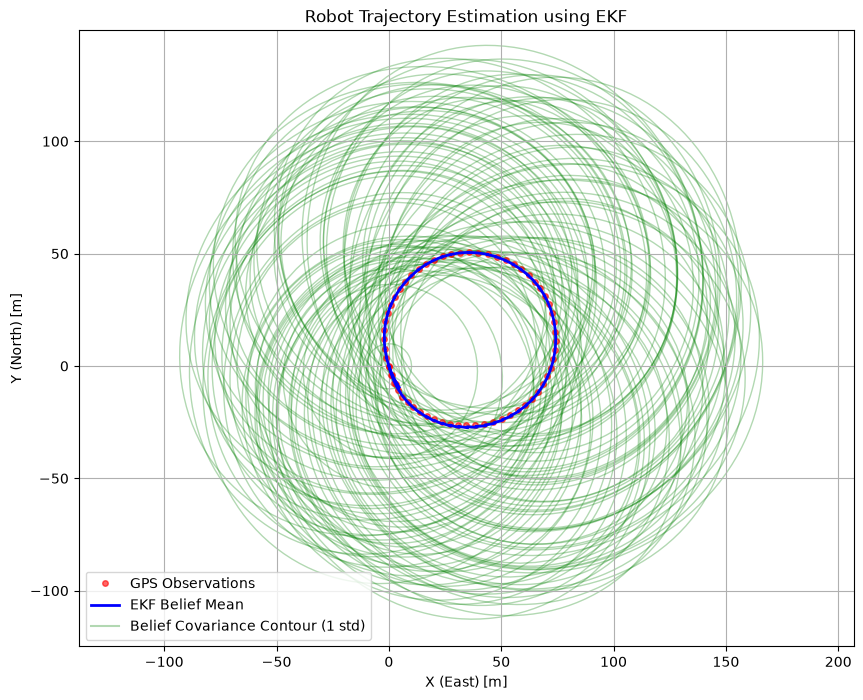

In [ ]:
df_gps = pd.read_csv('./data/gps.txt')
df_imu = pd.read_csv('./data/imu.txt')

df_gps.columns = df_gps.columns.str.strip()
df_imu.columns = df_imu.columns.str.strip()

df_gps = convert_gps_to_enu(df_gps)

X_0 = initialize_state(df_gps.iloc[0], df_gps.iloc[1])
P_0 = np.eye(5) * 1.0

R = np.diag([100, 100, 16, 16, 0.25])
Q = np.diag([10000, 10000])
H = np.array([[1, 0, 0, 0, 0],
              [0, 1, 0, 0, 0]])

history = run_ekf(df_imu, df_gps, X_0, P_0, R, Q, H)

ekf_x = [state[0, 0] for state in history['X']]
ekf_y = [state[1, 0] for state in history['X']]
covariances = [cov[0:2, 0:2] for cov in history['P']]



fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(df_gps['x_m'], df_gps['y_m'], 'r.', markersize=8, label='GPS Observations', alpha=0.6)
ax.plot(ekf_x, ekf_y, 'b-', linewidth=2, label='EKF Belief Mean')

step = max(len(ekf_x) // 100, 1)
for i in range(0, len(ekf_x), step):
    pos = (ekf_x[i], ekf_y[i])
    cov = covariances[i]
    plot_covariance_ellipse(pos, cov, ax, n_std=1.0, edgecolor='g', alpha=0.3)

ax.plot([], [], color='g', alpha=0.3, label='Belief Covariance Contour (1 std)')

ax.set_title('Robot Trajectory Estimation using EKF')
ax.set_xlabel('X (East) [m]')
ax.set_ylabel('Y (North) [m]')
ax.legend()
ax.grid(True)
ax.axis('equal')
plt.savefig('ekf_trajectory_cov.png', dpi=300)
plt.show()